# Delhi Air Quality (2015–2020): Seasonal Trends, Pollutant Co-variation Patterns and PM2.5 Prediction

**Data:** Central Pollution Control Board (CPCB) continuous monitoring data, daily city-level averages for Delhi,
1 Jan 2015 – 1 Jul 2020 (compiled in the public *Air Quality Data in India (2015–2020)* dataset).

**Questions**
1. How does PM2.5 in Delhi vary across seasons and years, and how often does it exceed the Indian 24-h standard (NAAQS, 60 µg/m³)?
2. Which pollutants vary together, and what does that suggest about the sources behind them? (PM2.5/PM10 ratio + PCA)
3. What happened to each pollutant during the COVID-19 lockdown (a natural experiment in reduced traffic/industry)?
4. How well can PM2.5 be predicted from co-measured pollutants, and which ones matter most?

> Scope note: this is an exploratory, data-driven study. PCA here is used to find co-variation patterns, **not** as a formal
> receptor model (e.g. PMF / CMB), and no meteorological data is included.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pathlib import Path

FIG = Path('../figures'); RES = Path('../results')
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
NAAQS_PM25_24H = 60   # µg/m3, NAAQS 2009 (CPCB)
NAAQS_PM10_24H = 100  # µg/m3

## 1. Load and clean the data

In [2]:
raw = pd.read_csv('../data/delhi_city_day_2015_2020.csv', parse_dates=['Date'])
print(raw.shape, raw['Date'].min().date(), '->', raw['Date'].max().date())
raw.isna().mean().round(3).to_frame('missing_fraction').T

(2009, 16) 2015-01-01 -> 2020-07-01


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
missing_fraction,0.0,0.0,0.001,0.038,0.001,0.001,0.0,0.004,0.0,0.055,0.042,0.0,0.0,0.389,0.005,0.005


**Cleaning decisions**
- `Xylene` is dropped (≈39% missing).
- Exact zeros in CO, NOx, Benzene and Toluene are physically implausible for Delhi daily means and are treated as sensor dropouts (set to NaN).
- Short gaps (≤ 7 days) are filled by time interpolation; longer gaps are left missing and those days are dropped only where an analysis needs complete rows.

In [3]:
POLL = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
df = raw.set_index('Date')[POLL + ['AQI']].copy()
zero_as_missing = ['CO','NOx','Benzene','Toluene']
print('zeros set to NaN:', (df[zero_as_missing] == 0).sum().to_dict())
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
df = df.asfreq('D')
df[POLL] = df[POLL].interpolate(method='time', limit=7)

def season(m):   # IMD season definitions
    return {1:'Winter',2:'Winter',3:'Pre-monsoon',4:'Pre-monsoon',5:'Pre-monsoon',
            6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon'}.get(m, 'Post-monsoon')
SEASONS = ['Winter','Pre-monsoon','Monsoon','Post-monsoon']
df['Year'] = df.index.year; df['Month'] = df.index.month
df['Season'] = pd.Categorical(df['Month'].map(season), SEASONS, ordered=True)
print('Remaining missing after cleaning:'); print(df[POLL].isna().sum().to_dict())
df[POLL].describe().round(1)

zeros set to NaN: {'CO': 87, 'NOx': 2, 'Benzene': 8, 'Toluene': 108}
Remaining missing after cleaning:
{'PM2.5': 0, 'PM10': 51, 'NO': 0, 'NO2': 0, 'NOx': 0, 'NH3': 0, 'CO': 77, 'SO2': 95, 'O3': 74, 'Benzene': 0, 'Toluene': 91}


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene
count,2009.0,1958.0,2009.0,2009.0,2009.0,2009.0,1932.0,1914.0,1935.0,2009.0,1918.0
mean,117.1,233.4,39.0,50.8,58.6,42.0,2.1,15.9,51.2,3.5,18.0
std,82.9,121.5,33.4,22.7,37.7,17.3,2.6,8.0,26.0,2.4,15.1
min,10.2,18.6,3.6,10.6,0.2,6.8,0.0,2.3,6.9,0.0,0.2
25%,57.1,137.5,15.9,33.9,31.2,31.1,1.0,10.3,33.7,1.9,7.2
50%,94.5,217.8,27.2,47.2,52.8,38.0,1.3,14.5,44.3,3.0,13.6
75%,153.0,312.5,50.7,63.6,75.4,48.7,1.9,19.8,60.7,4.7,23.7
max,685.4,796.9,221.0,162.5,254.8,166.7,30.4,71.6,257.7,20.6,103.0


## 2. Temporal trends and NAAQS exceedance

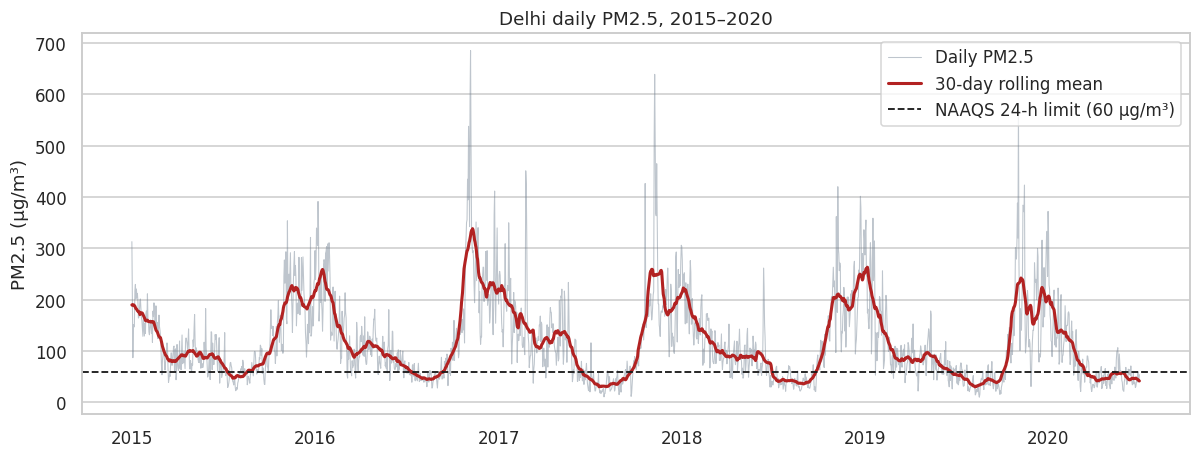

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(df.index, df['PM2.5'], color='slategray', alpha=0.45, lw=0.7, label='Daily PM2.5')
ax.grid(axis='x', visible=False)
ax.plot(df.index, df['PM2.5'].rolling(30, center=True, min_periods=15).mean(), color='firebrick', lw=2, label='30-day rolling mean')
ax.axhline(NAAQS_PM25_24H, color='k', ls='--', lw=1.2, label='NAAQS 24-h limit (60 µg/m³)')
ax.set(title='Delhi daily PM2.5, 2015–2020', ylabel='PM2.5 (µg/m³)', xlabel='')
ax.legend(loc='upper right'); plt.savefig(FIG/'fig01_pm25_timeseries.png'); plt.show()

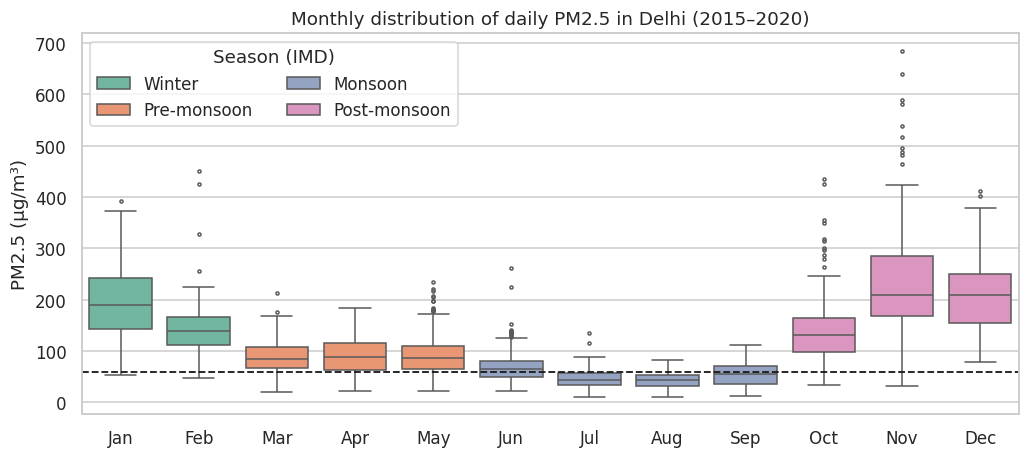

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
2015,175.7,153.9,80.3,91.6,97.1,85.8,52.7,56.9,74.2,132.1,227.7,183.9
2016,258.5,145.0,94.9,119.0,92.9,80.1,56.0,45.6,64.6,167.8,306.0,232.4
2017,199.4,171.9,109.2,117.3,129.6,61.5,34.7,36.6,52.4,146.7,249.8,189.3
2018,189.8,137.9,99.3,90.5,88.5,81.0,41.6,41.0,45.3,134.3,202.3,229.6
2019,204.3,122.3,84.2,82.3,89.7,63.8,46.7,34.1,40.1,123.7,205.4,205.2
2020,157.1,121.5,57.5,44.9,55.4,46.7,54.0,NaN,NaN,NaN,NaN,NaN


In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.boxplot(data=df.reset_index(), x='Month', y='PM2.5', hue='Season', dodge=False, palette='Set2', ax=ax, fliersize=2)
ax.axhline(NAAQS_PM25_24H, color='k', ls='--', lw=1.2)
ax.set_xticks(range(12)); ax.set_xticklabels(month_names)
ax.set(title='Monthly distribution of daily PM2.5 in Delhi (2015–2020)', ylabel='PM2.5 (µg/m³)', xlabel='')
ax.legend(title='Season (IMD)', loc='upper left', ncol=2)
plt.savefig(FIG/'fig02_monthly_boxplot.png'); plt.show()

monthly = df.pivot_table(index='Year', columns='Month', values='PM2.5', aggfunc='mean').round(1)
monthly.columns = month_names[:monthly.shape[1]]
monthly.to_csv(RES/'monthly_mean_pm25.csv'); monthly

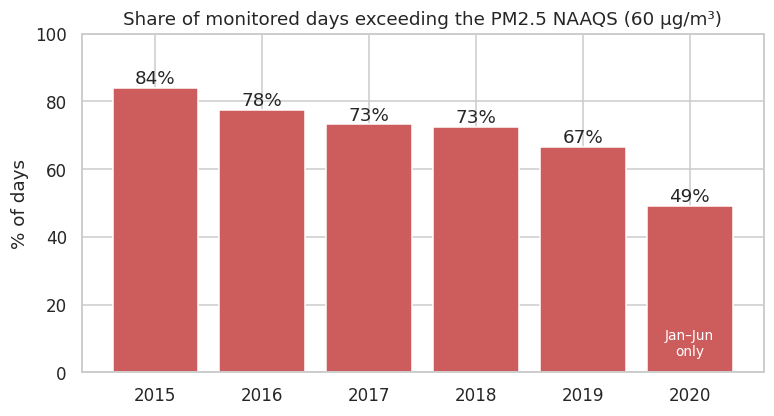

,days_monitored,days_above_60,mean_pm25,pct_days_above_60
Year,,,,
2015,365,307,117.3,84.1
2016,366,284,138.5,77.6
2017,365,267,124.5,73.2
2018,365,265,115.0,72.6
2019,365,243,108.5,66.6
2020,183,90,80.3,49.2


In [6]:
exc = df.groupby('Year').agg(days_monitored=('PM2.5','count'),
                             days_above_60=('PM2.5', lambda s: (s > NAAQS_PM25_24H).sum()),
                             mean_pm25=('PM2.5','mean'))
exc['pct_days_above_60'] = (100*exc['days_above_60']/exc['days_monitored']).round(1)
exc['mean_pm25'] = exc['mean_pm25'].round(1)
exc.to_csv(RES/'exceedance_by_year.csv')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(exc.index.astype(str), exc['pct_days_above_60'], color='indianred')
ax.bar_label(bars, fmt='%.0f%%'); ax.set_ylim(0, 100)
ax.set(title='Share of monitored days exceeding the PM2.5 NAAQS (60 µg/m³)', ylabel='% of days', xlabel='')
ax.text(5, 5, 'Jan–Jun\nonly', ha='center', fontsize=9, color='white')
plt.savefig(FIG/'fig03_exceedance_by_year.png'); plt.show()
exc

## 3. What the pollutant mix says about sources

### 3a. PM2.5 / PM10 ratio
Fine particles (PM2.5) come mainly from **combustion** (vehicles, biomass/stubble burning, industry) and secondary aerosol formation,
while the coarse fraction (PM10 minus PM2.5) is dominated by **mechanical sources** such as road and construction dust and wind-blown soil.
A higher PM2.5/PM10 ratio therefore points to a more combustion-dominated aerosol.

**QA check:** days where PM2.5 > PM10 are physically impossible and are excluded here.

QA: 16 days with PM2.5 > PM10 excluded from ratio analysis (0.8% of days)


/tmp/ipykernel_284/1276775558.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df.reset_index(), x='Season', y='PM_ratio', palette='Set2', inner='quartile', cut=0, ax=ax)


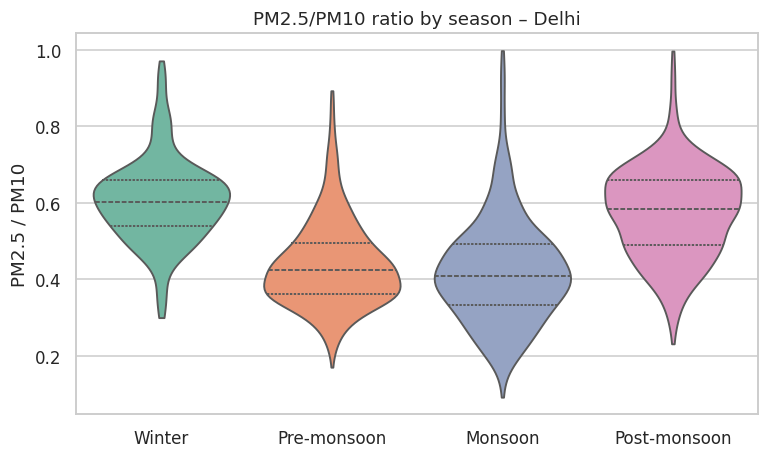

,count,mean,50%,std
Season,,,,
Winter,346.0,0.61,0.60,0.11
Pre-monsoon,551.0,0.44,0.42,0.11
Monsoon,586.0,0.42,0.41,0.14
Post-monsoon,459.0,0.57,0.58,0.12


In [7]:
df['PM_ratio'] = df['PM2.5'] / df['PM10']
# QA: PM2.5 is a subset of PM10, so a ratio > 1 is physically impossible. These days most likely arise because the
# city-average PM2.5 and PM10 are built from different sets of reporting stations. Exclude them from the ratio analysis.
bad = df['PM_ratio'] > 1
print(f'QA: {bad.sum()} days with PM2.5 > PM10 excluded from ratio analysis ({100*bad.mean():.1f}% of days)')
df.loc[bad, 'PM_ratio'] = np.nan
ratio = df.groupby('Season', observed=True)['PM_ratio'].describe()[['count','mean','50%','std']].round(2)
ratio.to_csv(RES/'pm_ratio_by_season.csv')

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=df.reset_index(), x='Season', y='PM_ratio', palette='Set2', inner='quartile', cut=0, ax=ax)
ax.set(title='PM2.5/PM10 ratio by season – Delhi', ylabel='PM2.5 / PM10', xlabel='')
plt.savefig(FIG/'fig04_pm_ratio_by_season.png'); plt.show()
ratio

### 3b. Correlation between pollutants

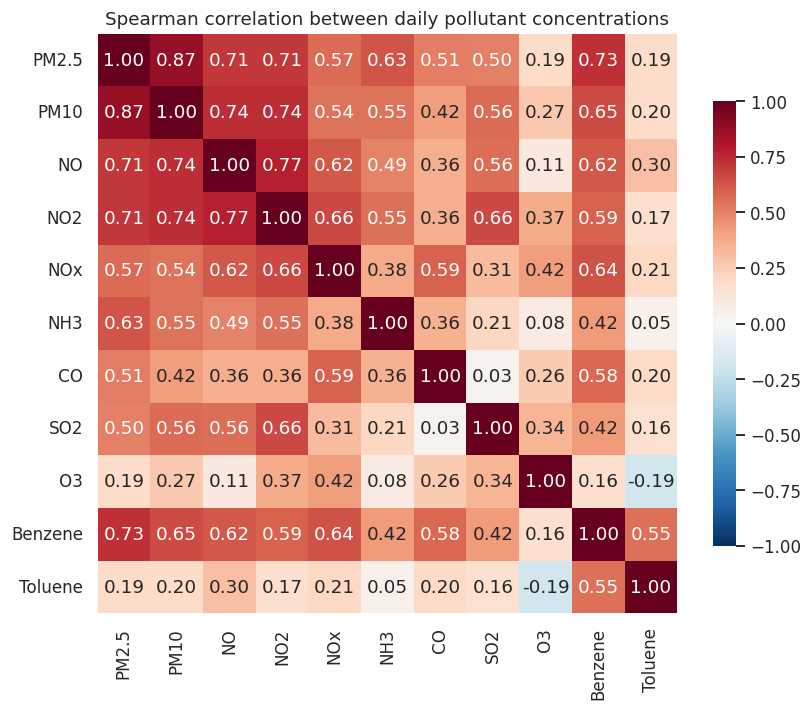

In [8]:
corr = df[POLL].corr(method='spearman')
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, cbar_kws={'shrink':0.75}, ax=ax)
ax.set_title('Spearman correlation between daily pollutant concentrations')
plt.savefig(FIG/'fig05_correlation_heatmap.png'); plt.show()
corr.round(2).to_csv(RES/'correlation_matrix.csv')

### 3c. Principal Component Analysis (exploratory source-pattern grouping)
PCA finds combinations of pollutants that rise and fall together. Pollutants that load strongly on the same component are likely
to share a source or a controlling process (e.g. the same emission type, or the same meteorological trapping).
`NOx` is excluded because it is essentially NO + NO2 and would double-count them. Data are log-transformed (concentrations are
right-skewed) and standardised before PCA.

rows used: 1911 | components with eigenvalue > 1: 3
explained variance: [49.  14.1 12.3  8.2  5.1] | cumulative: 75.5 %


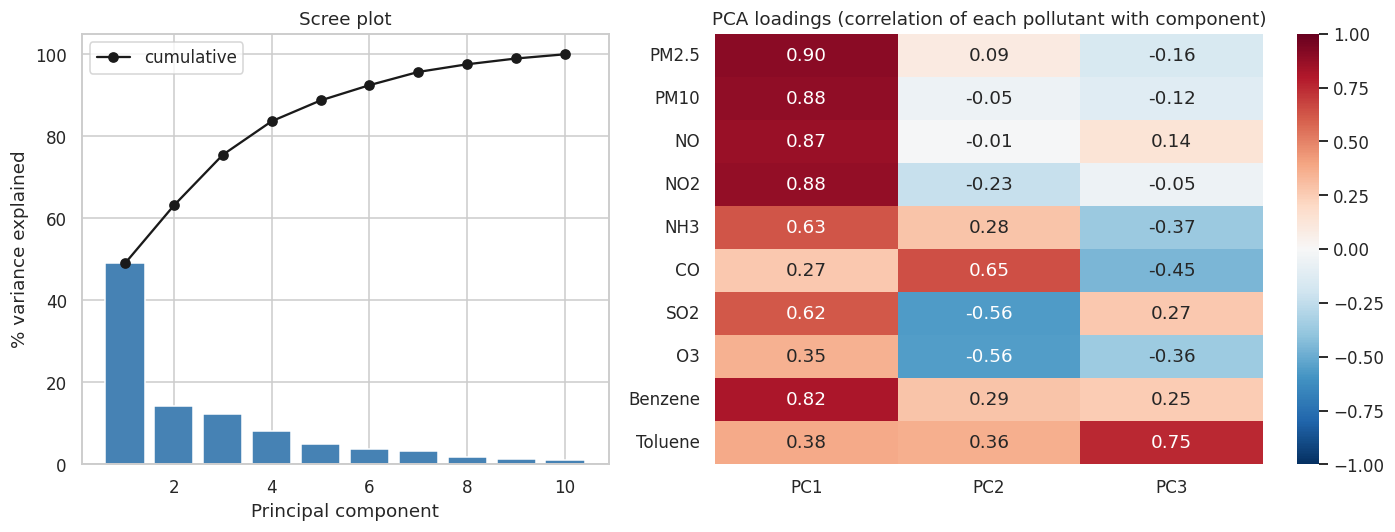

,PC1,PC2,PC3
PM2.5,0.90,0.09,-0.16
PM10,0.88,-0.05,-0.12
NO,0.87,-0.01,0.14
NO2,0.88,-0.23,-0.05
NH3,0.63,0.28,-0.37
CO,0.27,0.65,-0.45
SO2,0.62,-0.56,0.27
O3,0.35,-0.56,-0.36
Benzene,0.82,0.29,0.25
Toluene,0.38,0.36,0.75


In [9]:
PCA_VARS = ['PM2.5','PM10','NO','NO2','NH3','CO','SO2','O3','Benzene','Toluene']
X = df[PCA_VARS].dropna()
Xs = StandardScaler().fit_transform(np.log1p(X))
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
n_keep = int((pca.explained_variance_ > 1).sum())   # Kaiser criterion
print('rows used:', len(X), '| components with eigenvalue > 1:', n_keep)
print('explained variance:', np.round(evr[:5]*100, 1), '| cumulative:', np.round(evr[:n_keep].sum()*100,1), '%')

loadings = pd.DataFrame(pca.components_[:n_keep].T * np.sqrt(pca.explained_variance_[:n_keep]),
                        index=PCA_VARS, columns=[f'PC{i+1}' for i in range(n_keep)])
loadings.round(3).to_csv(RES/'pca_loadings.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios':[1,1.3]})
axes[0].bar(range(1, len(evr)+1), evr*100, color='steelblue')
axes[0].plot(range(1, len(evr)+1), np.cumsum(evr)*100, 'o-', color='k', label='cumulative')
axes[0].set(title='Scree plot', xlabel='Principal component', ylabel='% variance explained'); axes[0].legend()
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('PCA loadings (correlation of each pollutant with component)')
plt.tight_layout(); plt.savefig(FIG/'fig06_pca_scree_loadings.png'); plt.show()
loadings.round(2)

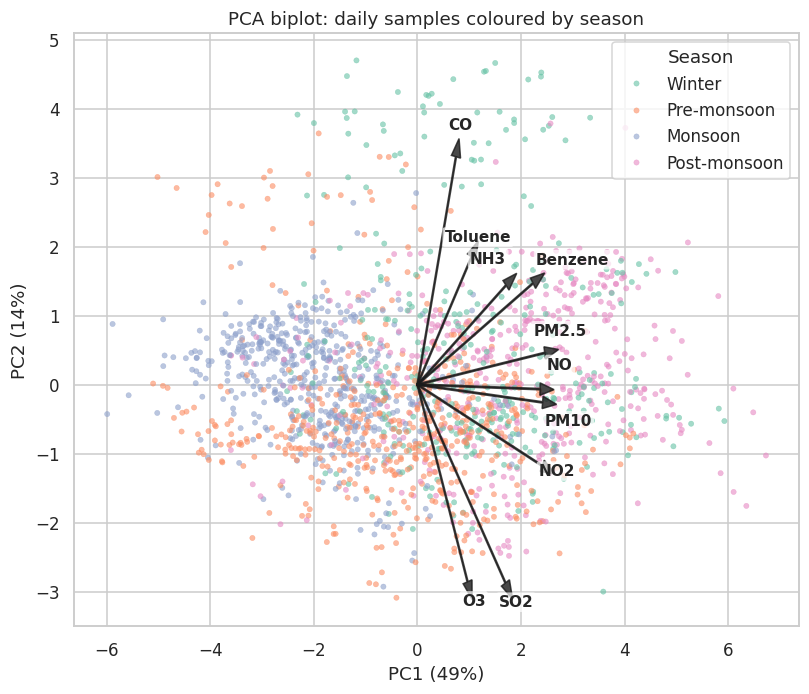

In [10]:
scores = pca.transform(Xs)[:, :2]
sc = pd.DataFrame(scores, index=X.index, columns=['PC1','PC2']).join(df['Season'])
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.scatterplot(data=sc, x='PC1', y='PC2', hue='Season', palette='Set2', s=12, alpha=0.6, ax=ax, edgecolor=None)
scale = np.abs(scores).max() * 0.9
for v, (a, b) in zip(PCA_VARS, pca.components_[:2].T):
    ax.arrow(0, 0, a*scale, b*scale, color='k', width=0.02, head_width=0.18, alpha=0.8)
    dx, dy = {'NH3':(-0.55,0.15), 'Benzene':(0.5,0.1), 'NO':(0.1,0.3), 'PM10':(0.2,-0.3), 'PM2.5':(0,0.2)}.get(v, (0,0))
    ax.text(a*scale*1.12+dx, b*scale*1.12+dy, v, fontsize=10, weight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
ax.set(title='PCA biplot: daily samples coloured by season', xlabel=f'PC1 ({evr[0]*100:.0f}%)', ylabel=f'PC2 ({evr[1]*100:.0f}%)')
plt.savefig(FIG/'fig07_pca_biplot.png'); plt.show()

## 4. Natural experiment: COVID-19 lockdown (25 Mar – 31 May 2020)
India's nationwide lockdown sharply reduced traffic and industrial activity. Comparing the same calendar window with previous years
shows which pollutants respond to these anthropogenic sources. A 3-year baseline (2017–2019) is used to reduce year-to-year noise.

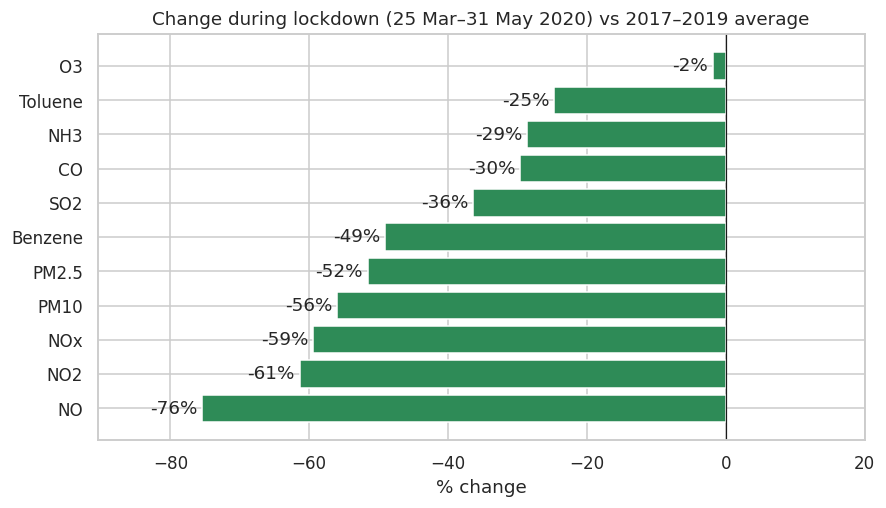

,baseline_2017_2019,lockdown_2020,pct_change
PM2.5,100.1,48.5,-51.6
PM10,261.7,115.1,-56.0
NO,39.7,9.7,-75.5
NO2,58.1,22.4,-61.4
NOx,52.1,21.2,-59.4
NH3,40.2,28.7,-28.7
CO,1.2,0.8,-29.6
SO2,23.7,15.1,-36.4
O3,50.6,49.7,-1.9
Benzene,3.2,1.6,-49.1


In [11]:
def window(y): return df.loc[f'{y}-03-25':f'{y}-05-31', POLL]
lock = window(2020).mean()
base = pd.concat([window(y) for y in (2017, 2018, 2019)]).mean()
lk = pd.DataFrame({'baseline_2017_2019': base, 'lockdown_2020': lock})
lk['pct_change'] = 100 * (lk['lockdown_2020'] - lk['baseline_2017_2019']) / lk['baseline_2017_2019']
lk = lk.round(1); lk.to_csv(RES/'lockdown_comparison.csv')

order = lk['pct_change'].sort_values().index
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ['seagreen' if v < 0 else 'indianred' for v in lk.loc[order, 'pct_change']]
bars = ax.barh(order, lk.loc[order, 'pct_change'], color=colors)
ax.bar_label(bars, fmt='%+.0f%%', padding=3); ax.axvline(0, color='k', lw=0.8)
ax.set(title='Change during lockdown (25 Mar–31 May 2020) vs 2017–2019 average', xlabel='% change', ylabel='')
ax.set_xlim(lk['pct_change'].min()-15, max(lk['pct_change'].max(), 0)+20)
plt.savefig(FIG/'fig08_lockdown_change.png'); plt.show()
lk

## 5. Predicting daily PM2.5 from co-measured pollutants

**Design choices (to avoid over-optimistic results)**
- **Time-based split:** train on 2015–2018, test on 2019–2020. A random split would leak information because consecutive days are highly correlated.
- **Two feature sets:**
  - **A – all co-pollutants incl. PM10.** PM10 contains PM2.5, so this is the "easy" case.
  - **B – gaseous pollutants only (no PM10).** Asks whether gas-phase tracers alone can explain PM2.5 – more informative about sources.
- Seasonality is encoded with sin/cos of day-of-year.
- A **climatology baseline** (training-period mean PM2.5 for each calendar month) shows how much the models add beyond "knowing the season".

In [12]:
m = df.copy()
doy = m.index.dayofyear
m['doy_sin'] = np.sin(2*np.pi*doy/365.25); m['doy_cos'] = np.cos(2*np.pi*doy/365.25)
GAS = ['NO','NO2','NH3','CO','SO2','O3','Benzene','Toluene']
FEATS = {'A: all co-pollutants (incl. PM10)': ['PM10'] + GAS + ['doy_sin','doy_cos'],
         'B: gaseous pollutants only':        GAS + ['doy_sin','doy_cos']}
train = m.loc[:'2018-12-31']; test = m.loc['2019-01-01':]

def metrics(y, p): return dict(R2=r2_score(y, p), RMSE=mean_squared_error(y, p)**0.5, MAE=mean_absolute_error(y, p))

rows, preds, models = [], {}, {}
clim = train.groupby('Month')['PM2.5'].mean()
t = test.dropna(subset=['PM2.5'])
rows.append({'feature_set':'Baseline', 'model':'Monthly climatology', 'n_test':len(t), **metrics(t['PM2.5'], t['Month'].map(clim))})

for fs, cols in FEATS.items():
    tr = train.dropna(subset=cols+['PM2.5']); te = test.dropna(subset=cols+['PM2.5'])
    for name, mdl in [('Linear Regression', LinearRegression()),
                      ('Random Forest', RandomForestRegressor(n_estimators=400, min_samples_leaf=3, n_jobs=-1, random_state=42))]:
        mdl.fit(tr[cols], tr['PM2.5']); p = mdl.predict(te[cols])
        rows.append({'feature_set':fs, 'model':name, 'n_test':len(te), **metrics(te['PM2.5'], p)})
        preds[(fs, name)] = pd.Series(p, index=te.index); models[(fs, name)] = (mdl, cols, te)

res = pd.DataFrame(rows).round(3); res.to_csv(RES/'model_metrics.csv', index=False); res

,feature_set,model,n_test,R2,RMSE,MAE
0,Baseline,Monthly climatology,548,0.409,59.908,44.915
1,A: all co-pollutants (incl. PM10),Linear Regression,548,0.886,26.279,17.491
2,A: all co-pollutants (incl. PM10),Random Forest,548,0.939,19.329,14.288
3,B: gaseous pollutants only,Linear Regression,548,0.699,42.773,27.154
4,B: gaseous pollutants only,Random Forest,548,0.788,35.895,24.965


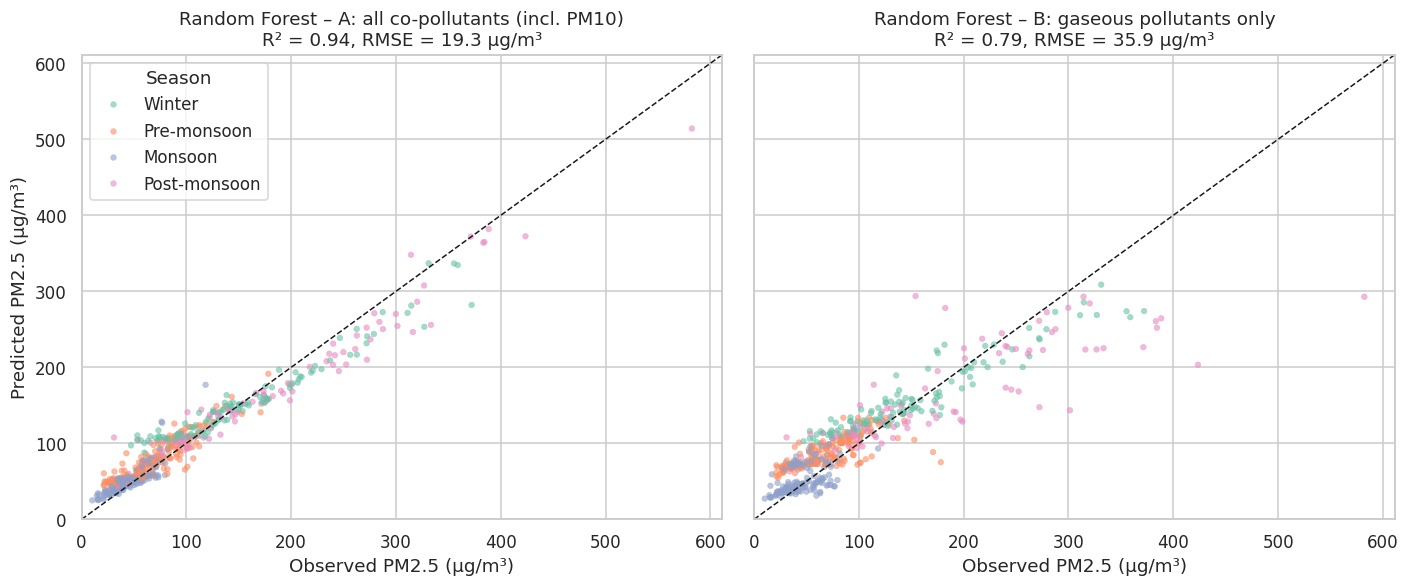

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, fs in zip(axes, FEATS):
    p = preds[(fs, 'Random Forest')]; y = test.loc[p.index, 'PM2.5']
    r = res[(res.feature_set==fs)&(res.model=='Random Forest')].iloc[0]
    sns.scatterplot(x=y, y=p, hue=test.loc[p.index,'Season'], palette='Set2', s=14, alpha=0.6, edgecolor=None, ax=ax,
                    legend=(ax is axes[0]))
    lim = [0, max(y.max(), p.max())*1.05]; ax.plot(lim, lim, 'k--', lw=1)
    ax.set(xlim=lim, ylim=lim, xlabel='Observed PM2.5 (µg/m³)', title=f'Random Forest – {fs}\nR² = {r.R2:.2f}, RMSE = {r.RMSE:.1f} µg/m³')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
plt.tight_layout(); plt.savefig(FIG/'fig09_predicted_vs_observed.png'); plt.show()

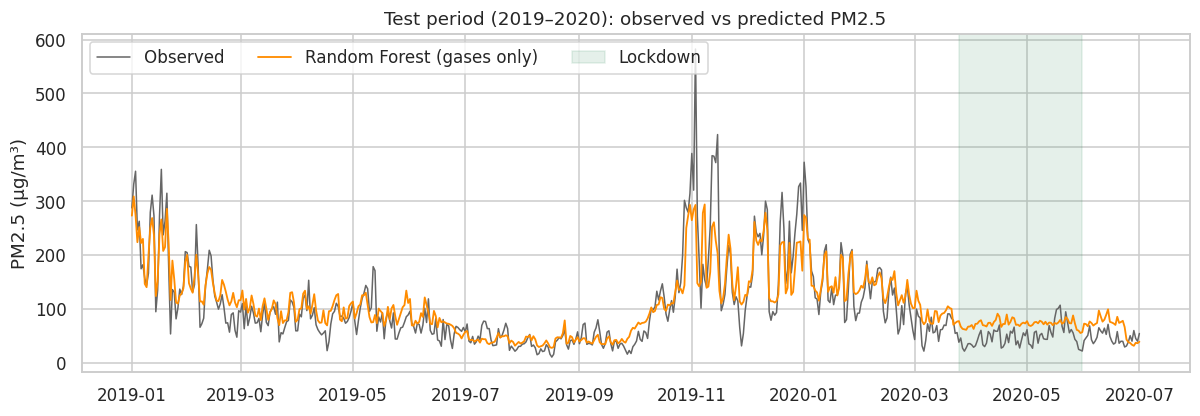

,mean_bias_ugm3,mean_observed_pm25,bias_pct_of_observed
Test period excl. lockdown,4.6,106.3,4.0
Lockdown (25 Mar–31 May 2020),24.1,48.5,50.0


In [14]:
fs = 'B: gaseous pollutants only'
p = preds[(fs, 'Random Forest')]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test['PM2.5'], color='0.4', lw=1, label='Observed')
ax.plot(p.index, p, color='darkorange', lw=1.2, label='Random Forest (gases only)')
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-05-31'), color='seagreen', alpha=0.12, label='Lockdown')
ax.set(title='Test period (2019–2020): observed vs predicted PM2.5', ylabel='PM2.5 (µg/m³)'); ax.legend(ncol=3)
plt.savefig(FIG/'fig10_test_period_timeseries.png'); plt.show()

# Does the gas-only model behave differently during lockdown?
resid = (p - test.loc[p.index, 'PM2.5'])
in_lock = (resid.index >= '2020-03-25') & (resid.index <= '2020-05-31')
lock_bias = pd.DataFrame({'mean_bias_ugm3': [resid[~in_lock].mean(), resid[in_lock].mean()],
                          'mean_observed_pm25': [test.loc[p.index[~in_lock],'PM2.5'].mean(), test.loc[p.index[in_lock],'PM2.5'].mean()]},
                         index=['Test period excl. lockdown', 'Lockdown (25 Mar–31 May 2020)']).round(1)
lock_bias['bias_pct_of_observed'] = (100*lock_bias['mean_bias_ugm3']/lock_bias['mean_observed_pm25']).round(0)
lock_bias.to_csv(RES/'lockdown_model_bias.csv'); lock_bias

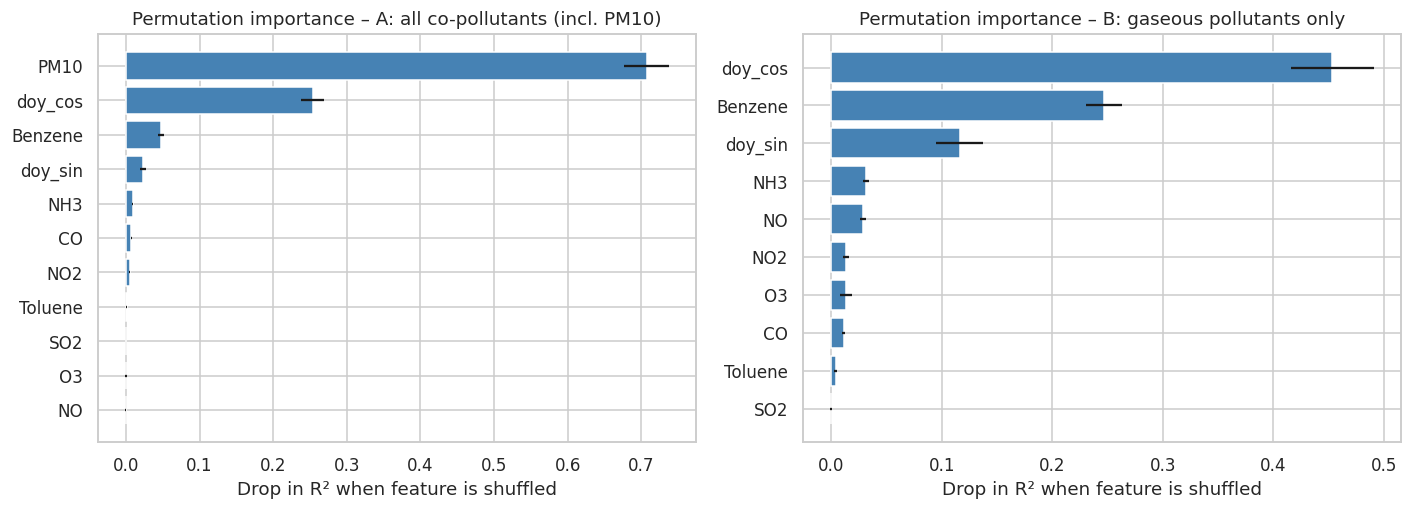

In [15]:
imp_rows = []
for fs in FEATS:
    mdl, cols, te = models[(fs, 'Random Forest')]
    pi = permutation_importance(mdl, te[cols], te['PM2.5'], n_repeats=20, random_state=42, n_jobs=-1)
    imp_rows += [{'feature_set':fs, 'feature':c, 'importance':i, 'std':s} for c, i, s in zip(cols, pi.importances_mean, pi.importances_std)]
imp = pd.DataFrame(imp_rows); imp.round(4).to_csv(RES/'feature_importance.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, fs in zip(axes, FEATS):
    d = imp[imp.feature_set==fs].sort_values('importance')
    ax.barh(d.feature, d.importance, xerr=d['std'], color='steelblue')
    ax.set(title=f'Permutation importance – {fs}', xlabel='Drop in R² when feature is shuffled')
plt.tight_layout(); plt.savefig(FIG/'fig11_feature_importance.png'); plt.show()

## 6. Limitations
- **City-average data:** station-level variation within Delhi is averaged out.
- **No meteorology:** wind speed, boundary-layer height, temperature and humidity strongly control PM2.5, especially in winter; they are not in this dataset.
- **PCA ≠ source apportionment:** components reflect co-variation, which can come from shared meteorology as well as shared sources. Formal apportionment requires chemical speciation (ions, OC/EC, metals) and receptor models such as PMF.
- **Distribution shift in the test period:** 2020 includes the lockdown, which changes the relationship between gaseous and particulate pollutants.

## 7. Possible extensions
1. Add ERA5 / IMD meteorology and quantify how much of the PM2.5 variation is weather-driven.
2. Repeat at station level using CPCB CAAQMS data (e.g. traffic-dominated vs residential stations).
3. Use speciated PM data with Positive Matrix Factorization (EPA PMF 5.0) for true source apportionment.
4. Link post-monsoon peaks to satellite fire counts (NASA FIRMS) in Punjab/Haryana.